### Payment_Fraud_Detection-and-Risk_Monitoring_Analytics

In [1]:
# Fraud Detection Project

In [2]:
# Import pandas Libraries:

In [2]:
import pandas as pd

In [3]:
bank_df = pd.read_csv("bank_transaction.csv")  # Load Dataset 

In [4]:
bank_df.shape  # Check all the number of rows and columns in datasets

(2512, 16)

In [6]:
print(f"Rows: {bank_df.shape[0]}")
print(f"Columns: {bank_df.shape[1]}")   # More CLear way to check rows and columns

Rows: 2512
Columns: 16


In [7]:
bank_df.dtypes  #WHat are the Datatypes of all columns name is this correct

TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object

In [8]:
bank_df.info()  # More Clear ways to understand data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [9]:
bank_df.isnull().sum()  #Check Any null values present or not in this dataset

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [10]:
(bank_df.isnull().sum() / len(bank_df)) * 100    #Calculates the percentage of missing (null) values in each column

TransactionID              0.0
AccountID                  0.0
TransactionAmount          0.0
TransactionDate            0.0
TransactionType            0.0
Location                   0.0
DeviceID                   0.0
IP Address                 0.0
MerchantID                 0.0
Channel                    0.0
CustomerAge                0.0
CustomerOccupation         0.0
TransactionDuration        0.0
LoginAttempts              0.0
AccountBalance             0.0
PreviousTransactionDate    0.0
dtype: float64

In [11]:
bank_df.duplicated().sum() #Check is there any duplicate transactions

np.int64(0)

In [12]:
bank_df.describe()  #What are the basic statistics of numeric columns

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [13]:
bank_df.head(2)  # CHeck few datasamples

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35


In [14]:
# Now check is IP addresses are valid

In [15]:
import re  #Regular Expression

pattern = r'^(\d{1,3}\.){3}\d{1,3}$'

bank_df['Valid_IP'] = bank_df['IP Address'].astype(str).str.match(pattern)
bank_df[['IP Address','Valid_IP']]

,IP Address,Valid_IP
0,162.198.218.92,True
1,13.149.61.4,True
2,215.97.143.157,True
3,200.13.225.150,True
4,65.164.3.100,True
...,...,...
2507,21.157.41.17,True
2508,49.174.157.140,True
2509,58.1.27.124,True
2510,21.190.11.223,True


In [16]:
(bank_df['TransactionAmount'] <= 0).sum()  #Now Check are transaction amounts negative or zero

np.int64(0)

In [17]:
# Check dates logically consistents

bank_df['TransactionDate'] = pd.to_datetime(bank_df['TransactionDate'])
bank_df['PreviousTransactionDate'] = pd.to_datetime(bank_df['PreviousTransactionDate'])

invalid_dates = bank_df[
    bank_df['TransactionDate'] < bank_df['PreviousTransactionDate']
]

In [18]:
invalid_dates

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Valid_IP
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,True
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,True
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,True
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,True
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29,True
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42,True
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39,True
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22,True


In [19]:
len(invalid_dates)

2512

In [20]:
invalid_dates[['TransactionDate', 'PreviousTransactionDate']]

,TransactionDate,PreviousTransactionDate
0,2023-04-11 16:29:14,2024-11-04 08:08:08
1,2023-06-27 16:44:19,2024-11-04 08:09:35
2,2023-07-10 18:16:08,2024-11-04 08:07:04
3,2023-05-05 16:32:11,2024-11-04 08:09:06
4,2023-10-16 17:51:24,2024-11-04 08:06:39
...,...,...
2507,2023-04-26 17:09:36,2024-11-04 08:11:29
2508,2023-03-22 17:36:48,2024-11-04 08:11:42
2509,2023-08-21 17:08:50,2024-11-04 08:08:39
2510,2023-02-24 16:24:46,2024-11-04 08:12:22


In [21]:
# bank_df = bank_df[bank_df['TransactionDate'] >= bank_df['PreviousTransactionDate']]  # remove invalid records

In [22]:
if len(invalid_dates) > 0:
    print(f"Found {len(invalid_dates)} invalid records")
else:
    print("No invalid date records found")

Found 2512 invalid records


In [23]:
# 1. Find invalid records
# #invalid_dates = bank_df[bank_df['TransactionDate'] < bank_df['PreviousTransactionDate']]

# 2. Count them
# print(f"Invalid records: {len(invalid_dates)}")

# 3. Inspect them
# display(invalid_dates.head())

# 4. Remove them if necessary
# bank_df = bank_df[bank_df['TransactionDate'] >= bank_df['PreviousTransactionDate']]

In [24]:
bank_df[(bank_df['CustomerAge'] < 18) | (bank_df['CustomerAge'] > 100)]  # Are customer ages realistic

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Valid_IP


In [25]:
bank_df['TransactionAmount'].describe()  #Which transaction types dominates

count    2512.000000
mean      297.593778
std       291.946243
min         0.260000
25%        81.885000
50%       211.140000
75%       414.527500
max      1919.110000
Name: TransactionAmount, dtype: float64

In [26]:
bank_df['Channel'].value_counts()  # WHich channels are most used

Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64

<Axes: xlabel='TransactionDate'>

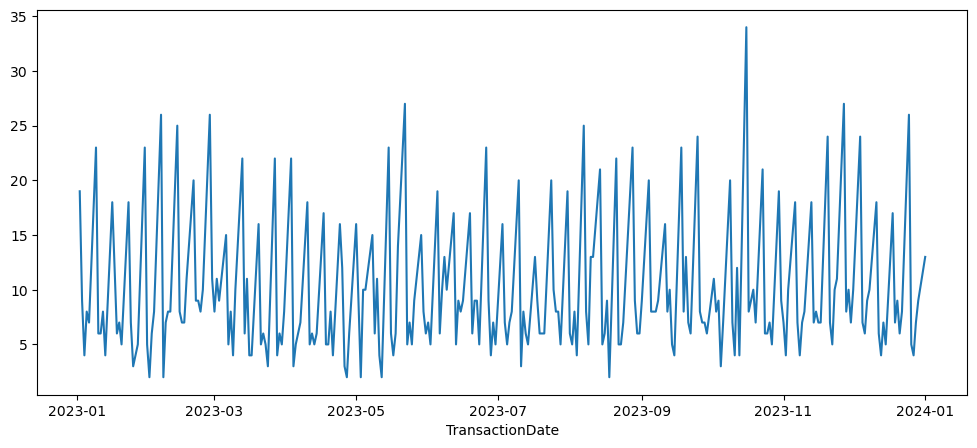

In [27]:
daily_txn = bank_df.groupby(bank_df['TransactionDate'].dt.date).size()

daily_txn.plot(figsize=(12,5))

In [28]:
bank_df['TimeGap_Hours'] = (
    bank_df['TransactionDate'] -
    bank_df['PreviousTransactionDate']
).dt.total_seconds()/3600  #Time elapsed since previous transactions

In [29]:
bank_df['Amount_Balance_Ratio'] = (
    bank_df['TransactionAmount'] /
    bank_df['AccountBalance']
)  # Transaction amount vs balance ratio

In [30]:
bank_df.sort_values(
    'LoginAttempts',
    ascending=False
)[['AccountID','LoginAttempts']]  #Accounts with high login attempts

,AccountID,LoginAttempts
953,AC00187,5
26,AC00441,5
394,AC00326,5
1584,AC00358,5
414,AC00495,5
...,...,...
861,AC00383,1
862,AC00450,1
863,AC00086,1
864,AC00156,1


In [31]:
bank_df.groupby('AccountID')['DeviceID'].nunique() \
  .sort_values(ascending=False)  #Multiple devices used by same account

AccountID
AC00362    12
AC00460    12
AC00202    12
AC00363    12
AC00456    11
           ..
AC00469     1
AC00168     1
AC00180     1
AC00199     1
AC00440     1
Name: DeviceID, Length: 495, dtype: int64

In [35]:
bank_df.groupby('AccountID')['Location'].nunique() \
  .sort_values(ascending=False)  #Mulitple location used by same account

AccountID
AC00363    11
AC00202    11
AC00257    11
AC00480    10
AC00225    10
           ..
AC00117     1
AC00199     1
AC00134     1
AC00180     1
AC00440     1
Name: Location, Length: 495, dtype: int64

In [36]:
txn_velocity = bank_df.groupby('AccountID').size()

txn_velocity.sort_values(ascending=False) #Transaction velocity per account

AccountID
AC00202    12
AC00460    12
AC00363    12
AC00362    12
AC00456    11
           ..
AC00044     1
AC00238     1
AC00472     1
AC00476     1
AC00112     1
Length: 495, dtype: int64

In [37]:
Q1 = bank_df['TransactionAmount'].quantile(0.25)
Q3 = bank_df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

outliers = bank_df[
    (bank_df['TransactionAmount'] < Q1 - 1.5*IQR) |
    (bank_df['TransactionAmount'] > Q3 + 1.5*IQR)]        #IQR-based outlier detection   

In [40]:
from scipy.stats import zscore

bank_df['z_score'] = zscore(bank_df['TransactionAmount'])

outliers = bank_df[
    abs(bank_df['z_score']) > 3
]   # Z-Score outlier detection

In [41]:
from sklearn.ensemble import IsolationForest

features = bank_df[['TransactionAmount',
               'AccountBalance',
               'LoginAttempts']]

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

bank_df['Anomaly'] = model.fit_predict(features) #Isolation Forest anomalies

In [42]:
bank_df[bank_df['Anomaly']==-1]['Location'].value_counts() #Do anomalies cluster by location

Location
Jacksonville        3
Los Angeles         3
Kansas City         3
El Paso             3
Columbus            3
Virginia Beach      3
Houston             2
Philadelphia        2
Colorado Springs    2
San Diego           2
New York            2
Fort Worth          2
Detroit             2
Phoenix             2
Chicago             1
Atlanta             1
Omaha               1
Tucson              1
Albuquerque         1
Austin              1
Sacramento          1
Miami               1
Charlotte           1
San Jose            1
Mesa                1
Portland            1
Oklahoma City       1
Nashville           1
Dallas              1
San Antonio         1
Seattle             1
Name: count, dtype: int64

In [43]:
bank_df[bank_df['Anomaly']==-1]['Channel'].value_counts()  #Cluster by channel

Channel
Branch    19
ATM       18
Online    14
Name: count, dtype: int64

In [45]:
corr = bank_df.corr(numeric_only=True)

corr   #Correlation between numeric features

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,Valid_IP,TimeGap_Hours,Amount_Balance_Ratio,z_score,Anomaly
TransactionAmount,1.000000,-0.025616,0.004359,-0.008445,-0.025165,NaN,0.024214,0.389860,1.000000,-0.129012
CustomerAge,-0.025616,1.000000,-0.017936,0.007653,0.319942,NaN,0.023285,-0.236644,-0.025616,0.008945
TransactionDuration,0.004359,-0.017936,1.000000,0.032639,0.005577,NaN,0.019697,0.009074,0.004359,-0.037576
LoginAttempts,-0.008445,0.007653,0.032639,1.000000,0.014999,NaN,-0.020750,-0.004339,-0.008445,-0.715081
AccountBalance,-0.025165,0.319942,0.005577,0.014999,1.000000,NaN,0.019377,-0.363401,-0.025165,-0.040039
Valid_IP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TimeGap_Hours,0.024214,0.023285,0.019697,-0.020750,0.019377,NaN,1.000000,-0.012938,0.024214,0.010182
Amount_Balance_Ratio,0.389860,-0.236644,0.009074,-0.004339,-0.363401,NaN,-0.012938,1.000000,0.389860,-0.021923
z_score,1.000000,-0.025616,0.004359,-0.008445,-0.025165,NaN,0.024214,0.389860,1.000000,-0.129012
Anomaly,-0.129012,0.008945,-0.037576,-0.715081,-0.040039,NaN,0.010182,-0.021923,-0.129012,1.000000


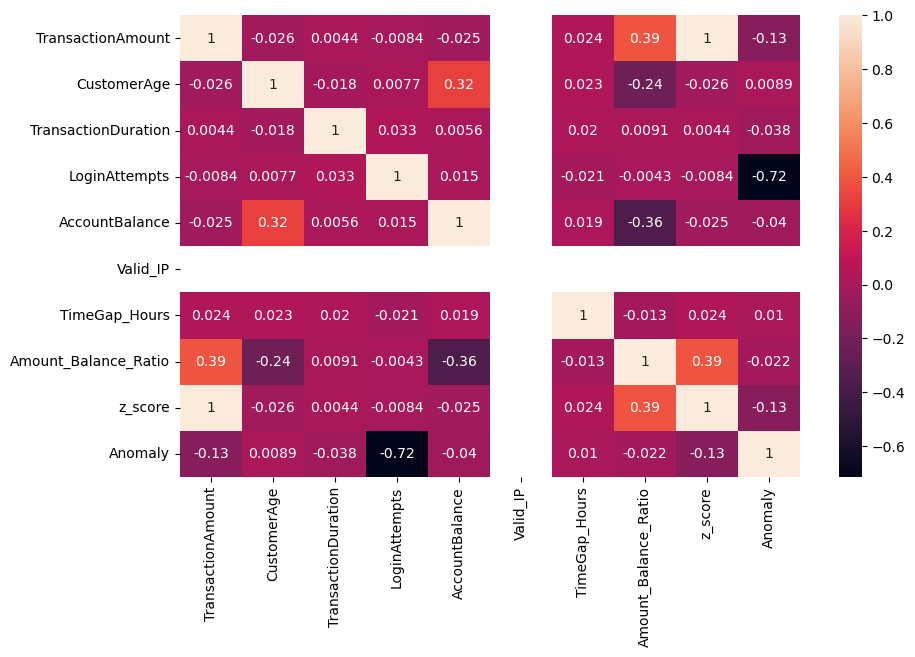

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()                        #Correlation heatmap

In [48]:
bank_df[['LoginAttempts',
    'TransactionAmount']].corr()  #Account balance vs transaction duration

,LoginAttempts,TransactionAmount
LoginAttempts,1.000000,-0.008445
TransactionAmount,-0.008445,1.000000


In [50]:
bank_df['AnomalyFlag'] = (
    bank_df['Anomaly'] == -1
).astype(int)

bank_df.corr(numeric_only=True)['AnomalyFlag']  #Features correlated with anomaly flag

TransactionAmount       0.129012
CustomerAge            -0.008945
TransactionDuration     0.037576
LoginAttempts           0.715081
AccountBalance          0.040039
Valid_IP                     NaN
TimeGap_Hours          -0.010182
Amount_Balance_Ratio    0.021923
z_score                 0.129012
Anomaly                -1.000000
AnomalyFlag             1.000000
Name: AnomalyFlag, dtype: float64

In [60]:
# Which features predict anomalies
from sklearn.ensemble import RandomForestClassifier

X = bank_df[['TransactionAmount',
        'AccountBalance',
        'LoginAttempts',
        'TransactionDuration']]

y = bank_df['AnomalyFlag']

rf = RandomForestClassifier()

rf.fit(X,y)

feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

accuracy_score(y_test,pred)  #Model Accuracy

0.9940357852882704

In [62]:
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, prob)   #ROC-AUC Score

0.9978750923872876

In [63]:
bank_df['RiskScore'] = (
      bank_df['Amount_Balance_Ratio']*0.4
    + bank_df['LoginAttempts']*0.3
    + bank_df['AnomalyFlag']*0.3
)

bank_df[['AccountID','RiskScore']] \
    .sort_values(
        'RiskScore',
        ascending=False
    ).head(10)        #Which accounts have highest risk score

,AccountID,RiskScore
2273,AC00357,3.458395
274,AC00454,3.253588
2191,AC00131,3.094597
1459,AC00460,2.769437
1258,AC00020,2.345194
2382,AC00119,2.314093
311,AC00285,2.303362
147,AC00161,2.288185
934,AC00456,2.269289
898,AC00083,2.212353


## HERE Create MYSQL Connections

In [7]:
!pip install mysql-connector-python  #Install mysql connector

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.7 MB 6.7 MB/s eta 0:00:03
   --- ------------------------------------ 1.6/17.7 MB 5.7 MB/s eta 0:00:03
   ---- ----------------------------------- 2.1/17.7 MB 5.0 MB/s eta 0:00:04
   ----- ---------------------------------- 2.4/17.7 MB 3.2 MB/s eta 0:00:05
   ----- ---------------------------------- 2.4/17.7 MB 3.2 MB/s eta 0:00:05
   ----- ---------------------------------- 2.4/17.7 MB 3.2 MB/s eta 0:00:05
   ------- -------------------------------- 3.1/17.7 MB 2.2 MB/s eta 0:00:07
   -------- ------------------------------- 3.7/17.7 MB 2.4 MB/s eta 0:00:06
   --------- ------------------------------ 4.2/17.7 MB 2.4 MB/s eta 0:00:06
   ---------- ----------------------------- 4.7/17.7 MB 2.3 MB/s eta 0:00:06
   ----------- ---------------------------- 5.0/17.7 MB 2.2 MB/s eta 0:00:06
   ------------ --------------------------- 5.5/17.7 MB 2.2 MB/s eta 0:00:06
   ---

In [15]:
#Here import MySQL connector
import mysql.connector

In [13]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Manish@212121",
    database="banking"
)

cursor = conn.cursor()

cursor.execute("""
SELECT COUNT(*)
FROM bank_transaction
""")

print(cursor.fetchone())

(2512,)


In [14]:
cursor.execute("SHOW TABLES")

for table in cursor:
    print(table)

('bank_transaction',)


## MOVE to MYSQL WorkBench

In [16]:
## For more Solving Analysis Questions

In [1]:
import shutil
shutil.copy('your_notebook.ipynb', 'C:/Users/YourName/Desktop/your_notebook.ipynb')

FileNotFoundError: [Errno 2] No such file or directory: 'your_notebook.ipynb'

In [2]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Owner
['.anaconda', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.virtual_documents', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'bank_transaction.csv', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2422ce7b-3251-11f1-a514-cc7cbf90542c}.TM.blf', 'NTUSER.DAT{2422ce7b-3251-11f1-a514-cc7cbf90542c}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2422ce7b-3251-11f1-a514-cc7cbf90542c}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Payment_Fraud_Detection-and-Risk_Monitoring_Analytics.ipynb', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled Folder', 'Untitled.ipynb', 'untitled.md', 'Videos']


In [3]:
import shutil
shutil.copy('Payment_Fraud_Detection-and-Risk_Monitoring_Analytics.ipynb', 'C:/Users/Owner/Desktop/Payment_Fraud_Detection-and-Risk_Monitoring_Analytics.ipynb')

'C:/Users/Owner/Desktop/Payment_Fraud_Detection-and-Risk_Monitoring_Analytics.ipynb'

In [ ]:
'C:/Users/Owner/Desktop/Payment_Fraud_Detection-and-Risk_Monitoring_Analytics.ipynb'